✅ PROJECT_ROOT определён: c:\Users\максим\Desktop\to_show\compare_competencies
✅ sys.path обновлён для импорта src

Загружено рыночных навыков: 71
Загружено маппингов компетенций: 44

Загружены профили студентов:
  base: 31 компетенций
  dc: 38 компетенций
  top_dc: 54 компетенций

🚀 Начинаем gap-анализ...

--- BASE ---
  Компетенций: 31
  Соответствующих навыков: 87
  Покрытие рынка: 11.27%
  Взвешенное покрытие: 22.38%
  Дефицитов высокого спроса: 9

   → Сохранено: comparison_report_base.json и recommendations_base.json
--- DC ---
  Компетенций: 38
  Соответствующих навыков: 98
  Покрытие рынка: 16.9%
  Взвешенное покрытие: 29.28%
  Дефицитов высокого спроса: 8

   → Сохранено: comparison_report_dc.json и recommendations_dc.json
--- TOP_DC ---
  Компетенций: 54
  Соответствующих навыков: 174
  Покрытие рынка: 39.44%
  Взвешенное покрытие: 76.52%
  Дефицитов высокого спроса: 2

   → Сохранено: comparison_report_top_dc.json и recommendations_top_dc.json

📊 Генерация графиков...


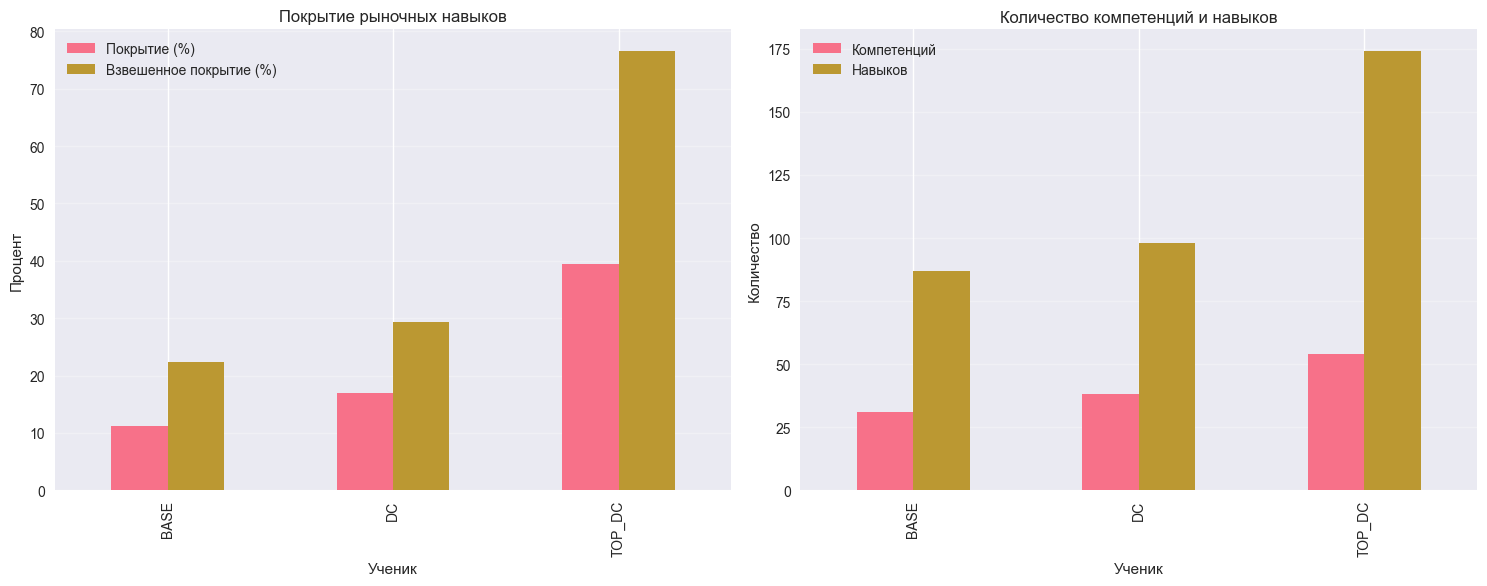


✅ Анализ успешно завершён!
Результаты сохранены в: c:\Users\максим\Desktop\to_show\compare_competencies\data\result


In [1]:
# 02_competency_matching.py — версия для запуска из папки notebooks/

import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


NOTEBOOK_DIR = Path.cwd() 
PROJECT_ROOT = NOTEBOOK_DIR.parent 

sys.path.insert(0, str(PROJECT_ROOT))


from src.analyzers.comparator import CompetencyComparator
from src.models.student import StudentProfile

print(f"✅ PROJECT_ROOT определён: {PROJECT_ROOT}")
print(f"✅ sys.path обновлён для импорта src\n")


# ====================== ПУТИ ======================
DATA_DIR = PROJECT_ROOT / "data"
MAPPING_PATH = DATA_DIR / "processed" / "competency_mapping.json"
MARKET_PATH = DATA_DIR / "processed" / "competency_frequency.json"

RESULTS_DIR = DATA_DIR / "result"
STUDENTS_DIR = DATA_DIR / "students"

# Создаём папки результатов
for profile in ["base", "dc", "top_dc"]:
    (RESULTS_DIR / profile).mkdir(parents=True, exist_ok=True)

# Настройки графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11


# ====================== ЗАГРУЗКА ДАННЫХ ======================
with open(MAPPING_PATH, encoding='utf-8') as f:
    competency_mapping = json.load(f)

with open(MARKET_PATH, encoding='utf-8') as f:
    market_skills = json.load(f)

print(f"Загружено рыночных навыков: {len(market_skills)}")
print(f"Загружено маппингов компетенций: {len(competency_mapping)}\n")


# ====================== ЗАГРУЗКА ПРОФИЛЕЙ СТУДЕНТОВ ======================
def load_student_competencies(filename: str):
    path = STUDENTS_DIR / filename
    try:
        with open(path, encoding='utf-8') as f:
            data = json.load(f)
        return data.get("компетенции") or data.get("навыки") or data.get("codes") or data.get("competencies", [])
    except Exception as e:
        print(f"⚠️ Не удалось загрузить {filename}: {e}")
        return []


students_data = {
    "base": load_student_competencies("base_competency.json"),
    "dc": load_student_competencies("dc_competency.json"),
    "top_dc": load_student_competencies("top_dc_competency.json")
}

print("Загружены профили студентов:")
for name, codes in students_data.items():
    print(f"  {name}: {len(codes)} компетенций")


# ====================== ИНИЦИАЛИЗАЦИЯ ======================
comparator = CompetencyComparator(competency_mapping)


# ====================== ЗАПУСК АНАЛИЗА ======================
print("\n🚀 Начинаем gap-анализ...\n")

results = {}
for student_name, comp_list in students_data.items():
    student = StudentProfile(
        student_id=student_name,
        name=student_name.upper(),
        competencies=comp_list
    )

    report = comparator.compare(student, market_skills)
    results[student_name] = report

    print(f"--- {student_name.upper()} ---")
    print(f"  Компетенций: {report.total_competencies}")
    print(f"  Соответствующих навыков: {report.total_mapped_skills}")
    print(f"  Покрытие рынка: {report.coverage_percent}%")
    print(f"  Взвешенное покрытие: {report.weighted_coverage_percent}%")
    print(f"  Дефицитов высокого спроса: {len(report.high_demand_gaps)}\n")

    # Сохранение с точными именами по твоей структуре
    student_dir = RESULTS_DIR / student_name
    student_dir.mkdir(parents=True, exist_ok=True)

    report_filename = f"comparison_report_{student_name}.json"
    rec_filename = f"recommendations_{student_name}.json"

    with open(student_dir / report_filename, "w", encoding="utf-8") as f:
        f.write(report.model_dump_json(indent=2))

    recommendations = {
        "student": student_name,
        "high_priority": [gap.skill for gap in report.high_demand_gaps[:10]],
        "medium_priority": [gap.skill for gap in report.medium_demand_gaps[:8]],
        "suggestion": report.recommendations[0] if report.recommendations 
                      else "Рекомендуется углубить знания в Deep Learning, MLOps и LLM."
    }

    with open(student_dir / rec_filename, "w", encoding="utf-8") as f:
        json.dump(recommendations, f, ensure_ascii=False, indent=2)

    print(f"   → Сохранено: {report_filename} и {rec_filename}")


# ====================== ВИЗУАЛИЗАЦИЯ ======================
print("\n📊 Генерация графиков...")

data = []
for name, report in results.items():
    data.append({
        "Ученик": name.upper(),
        "Компетенций": report.total_competencies,
        "Навыков": report.total_mapped_skills,
        "Покрытие (%)": report.coverage_percent,
        "Взвешенное покрытие (%)": report.weighted_coverage_percent
    })

df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df.plot(x="Ученик", y=["Покрытие (%)", "Взвешенное покрытие (%)"], kind="bar", ax=axes[0])
axes[0].set_title("Покрытие рыночных навыков")
axes[0].set_ylabel("Процент")
axes[0].grid(axis='y', alpha=0.3)

df.plot(x="Ученик", y=["Компетенций", "Навыков"], kind="bar", ax=axes[1])
axes[1].set_title("Количество компетенций и навыков")
axes[1].set_ylabel("Количество")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "summary_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Графики топ-дефицитов
for student_name, report in results.items():
    high_gaps = report.high_demand_gaps[:10]
    if not high_gaps:
        continue

    skills = [gap.skill for gap in high_gaps]
    freqs = [gap.frequency for gap in high_gaps]

    plt.figure(figsize=(10, 6))
    plt.barh(skills, freqs, color='salmon')
    plt.title(f"Топ-10 дефицитов высокого спроса — {student_name.upper()}")
    plt.xlabel("Частота в вакансиях")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / student_name / f"high_demand_deficits_{student_name}.png", 
                dpi=300, bbox_inches='tight')
    plt.close()

print("\n✅ Анализ успешно завершён!")
print(f"Результаты сохранены в: {RESULTS_DIR}")